# Granger Causality: Labor → Wage → Labor

**Hypothesis**: In each batch, agents share an equilibrium wage determined by the aggregate K/L ratio. When some agents raise their labor → aggregate effective labor rises → wage drops → other agents are forced to raise their own labor to smooth consumption.

**Chain**: $L_{-i,t-k} \rightarrow w_t \rightarrow \varepsilon^l_{i,t}$

**Why this notebook (not focal_trajectories)?** Focal agents span different batches, each with its own equilibrium wage. Cross-batch wage comparisons are meaningless. This notebook uses replay simulation data with *all* agents in *all* batches, so Granger tests run within-batch where wage is genuinely shared.

**Variable index map** (VAR_NAMES from replay_simulation.ipynb):

| Idx | Variable | Description |
|-----|----------|-------------|
| 0 | `a_t` | assets at start of period |
| 1 | `m_t` | money disposable |
| 2 | `v_t` | ability |
| 3 | `s_t` | superstar regime |
| 4 | `c_t` | consumption |
| 5 | `a_tp1` | next-period assets |
| 6 | `y_t` | income before tax |
| 7 | `mu_t` | borrowing constraint multiplier |
| 8 | `income_tax` | |
| 9 | `savings_tax` | |
| 10 | `wage` | batch-level market wage |
| 11 | `ret` | return to capital |
| 12 | `l_t` | labor |

**Three Granger tests per (batch, agent)**:
- **Test 1**: $L_{-i,t-k} \to w_t$ — do others' labor Granger-cause wage? (expected sign: negative)
- **Test 2**: $w_{t-k} \to \varepsilon^l_{i,t}$ — does wage Granger-cause residualized labor? (expected sign: negative)
- **Test 3**: $L_{-i,t-k} \to l_{i,t}$ — transitive: do others' labor Granger-cause my labor? (expected sign: negative)

**Focus**: Top-5 batches with largest max single-step wage drop.

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import glob
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns

from statsmodels.tsa.stattools import grangercausalitytests, adfuller, kpss
from tqdm.auto import tqdm

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [4]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
SIM_RUN_DIR    = '../simulated_run'
SIM_RUN_NAME   = None   # None → auto-pick latest
BURN_IN        = 100    # discard first N steps (warm-up)
TOP_K          = 5      # number of flagged batches
MAX_DROP_WINDOW = 5     # k in max_t (w[t] - w[t+k]) for k in 1..MAX_DROP_WINDOW
JUMP_LAMBDA    = 2.0    # event_count threshold: |Δw| > JUMP_LAMBDA * global_σ_w
GRANGER_MAX_LAG = 5    # max lag order for Granger tests (2)
GRANGER_TEST   = 'ssr_ftest'  # 'ssr_ftest' | 'ssr_chi2test' | 'lrtest'
SIG_LEVEL      = 0.05   # p-value threshold for significance
ADF_MAXLAG     = None   # None = auto (Schwert rule)
KPSS_NLAGS     = 'auto'
SAVE_FIGS      = False  # set True to save PNG figures
FIG_DIR        = '../comparison_plots/granger'
# ─────────────────────────────────────────────────────────────────────────────

# VAR_NAMES indices
IDX = {name: i for i, name in enumerate(
    ['a_t', 'm_t', 'v_t', 's_t', 'c_t', 'a_tp1', 'y_t', 'mu_t',
     'income_tax', 'savings_tax', 'wage', 'ret', 'l_t']
)}

if SAVE_FIGS:
    os.makedirs(FIG_DIR, exist_ok=True)

print('Config loaded.')
print(f'IDX: {IDX}')

Config loaded.
IDX: {'a_t': 0, 'm_t': 1, 'v_t': 2, 's_t': 3, 'c_t': 4, 'a_tp1': 5, 'y_t': 6, 'mu_t': 7, 'income_tax': 8, 'savings_tax': 9, 'wage': 10, 'ret': 11, 'l_t': 12}


In [5]:
# ── Load simulated data ────────────────────────────────────────────────────────
if SIM_RUN_NAME is None:
    candidates = [
        d for d in os.listdir(SIM_RUN_DIR)
        if os.path.isdir(os.path.join(SIM_RUN_DIR, d))
    ]
    if not candidates:
        raise FileNotFoundError(f'No subdirs found in {SIM_RUN_DIR}. Run replay_simulation.ipynb first.')
    SIM_RUN_NAME = sorted(candidates)[-1]  # pick lexicographically last
    print(f'Auto-selected run: {SIM_RUN_NAME}')

run_dir = os.path.join(SIM_RUN_DIR, SIM_RUN_NAME)

npz_files = glob.glob(os.path.join(run_dir, 'sim_data_*.npz'))
if not npz_files:
    raise FileNotFoundError(f'No sim_data_*.npz in {run_dir}')
npz_path = sorted(npz_files)[-1]

arr      = np.load(npz_path)
data_raw = arr['data'].astype(np.float64)   # (T, B, A, V)

with open(os.path.join(run_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

T_raw, B, A, V = data_raw.shape
data  = data_raw[BURN_IN:]           # (T, B, A, V)
T     = data.shape[0]

print(f'Loaded: {npz_path}')
print(f'Full shape: ({T_raw}, {B}, {A}, {V})  →  after burn-in: ({T}, {B}, {A}, {V})')
print(f'Meta: step={meta["source_step"]}, normalizer={meta["normalizer_type"]}')

# Sanity check: wage should be the same for all agents within a batch
b_test = 0
wage_spread = np.max(np.abs(data[:, b_test, :, IDX['wage']] - data[:, b_test, 0:1, IDX['wage']]), axis=1)
assert wage_spread.max() < 1e-5, f'Wage not batch-invariant! max spread={wage_spread.max():.6f}'
print('✓ Wage confirmed batch-invariant (all agents share same wage within a batch).')

Auto-selected run: Bewley_Hetero_ability_high_uncer_nonlinear_HardNorm-focal_from_step50000
Loaded: ../simulated_run/Bewley_Hetero_ability_high_uncer_nonlinear_HardNorm-focal_from_step50000/sim_data_10000steps.npz
Full shape: (10000, 32, 100, 13)  →  after burn-in: (9900, 32, 100, 13)
Meta: step=50000, normalizer=hard
✓ Wage confirmed batch-invariant (all agents share same wage within a batch).


In [6]:
# ── Compute jump metrics per batch ────────────────────────────────────────────
wage_series = data[:, :, 0, IDX['wage']]   # (T, B) — batch-level wage

global_sigma_w = wage_series.std()

rows = []
for b in range(B):
    w = wage_series[:, b]   # (T,)
    
    wage_std   = w.std()
    wage_mean  = w.mean()
    
    # max_drop: max over t and k of (w[t] - w[t+k])
    max_drop = 0.0
    max_drop_t = 0
    max_drop_k = 1
    for k in range(1, MAX_DROP_WINDOW + 1):
        drops = w[:-k] - w[k:]     # positive = wage fell
        idx_max = np.argmax(drops)
        if drops[idx_max] > max_drop:
            max_drop   = drops[idx_max]
            max_drop_t = idx_max
            max_drop_k = k
    
    # event_count: number of steps where |Δw| > JUMP_LAMBDA * global_σ_w
    event_count = int(np.sum(np.abs(np.diff(w)) > JUMP_LAMBDA * global_sigma_w))
    
    rows.append(dict(
        batch=b,
        wage_mean=wage_mean,
        wage_std=wage_std,
        max_drop=max_drop,
        max_drop_t=max_drop_t + BURN_IN,   # convert back to original step index
        max_drop_k=max_drop_k,
        event_count=event_count,
    ))

jump_df = pd.DataFrame(rows).sort_values('max_drop', ascending=False)
flagged_batches = list(jump_df.head(TOP_K)['batch'])

print(f'\nBatch wage jump metrics (sorted by max_drop):')
print(jump_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\nFlagged top-{TOP_K} batches: {flagged_batches}')


Batch wage jump metrics (sorted by max_drop):
 batch  wage_mean  wage_std  max_drop  max_drop_t  max_drop_k  event_count
    13     0.3694    0.0487    0.2865        1272           5            2
     3     0.3562    0.0734    0.2836        5708           5            1
    25     0.3108    0.1143    0.2835        3027           4            1
    22     0.3724    0.0395    0.2827        3017           5            1
    10     0.3486    0.0836    0.2803        3866           4            2
     0     0.3620    0.0646    0.2783        2201           5            0
     4     0.3674    0.0537    0.2783        4956           5            0
     8     0.3475    0.0842    0.2783        3369           5            4
    12     0.3714    0.0449    0.2768        9705           5            0
     5     0.3626    0.0618    0.2767        2215           5            1
    27     0.3367    0.0962    0.2738        9244           5            0
    24     0.3609    0.0655    0.2728        9728    

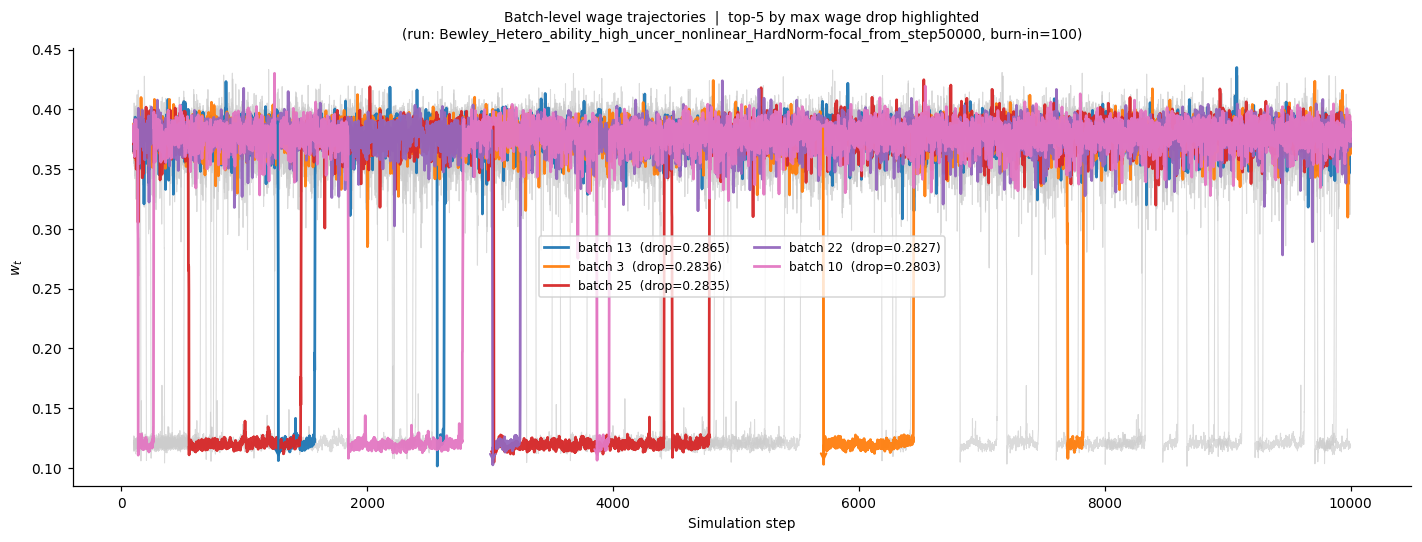

In [7]:
# ── Visualise all batch wage trajectories ─────────────────────────────────────
steps = np.arange(BURN_IN, BURN_IN + T)

fig, ax = plt.subplots(figsize=(13, 5))

# Non-flagged batches in light grey
for b in range(B):
    if b not in flagged_batches:
        ax.plot(steps, wage_series[:, b], color='#cccccc', lw=0.7, alpha=0.7)

# Flagged batches in colour with annotation
colors = plt.cm.tab10(np.linspace(0, 0.6, TOP_K))
flagged_info = jump_df.head(TOP_K).reset_index(drop=True)
for rank, (_, row) in enumerate(flagged_info.iterrows()):
    b   = int(row['batch'])
    col = colors[rank]
    w   = wage_series[:, b]
    ax.plot(steps, w, color=col, lw=1.8, alpha=0.95,
            label=f'batch {b}  (drop={row["max_drop"]:.4f})')
    # mark the max-drop event
    t0  = int(row['max_drop_t'] - BURN_IN)
    t1  = t0 + int(row['max_drop_k'])
    ax.annotate('',
        xy=(steps[t1], w[t1]), xytext=(steps[t0], w[t0]),
        arrowprops=dict(arrowstyle='->', color=col, lw=1.4))

ax.set_xlabel('Simulation step', fontsize=9)
ax.set_ylabel('$w_t$', fontsize=9)
ax.set_title(
    f'Batch-level wage trajectories  |  top-{TOP_K} by max wage drop highlighted\n'
    f'(run: {SIM_RUN_NAME}, burn-in={BURN_IN})', fontsize=9)
ax.legend(fontsize=8, frameon=True, ncol=2)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(FIG_DIR, 'fig_wage_extremes.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Helper functions (adapted from focal_trajectories.ipynb cells 12–13) ──────

def _residualize(y, controls):
    """OLS residuals of y ~ 1 + controls; NaN where any input is NaN."""
    nan_mask = np.isnan(y) | np.any(np.isnan(controls), axis=1)
    ok = ~nan_mask
    if ok.sum() < controls.shape[1] + 5:
        return np.full_like(y, np.nan, dtype=float)
    X = np.column_stack([np.ones(ok.sum()), controls[ok]])
    coef, _, _, _ = np.linalg.lstsq(X, y[ok], rcond=None)
    resid = np.full(len(y), np.nan)
    resid[ok] = y[ok] - X @ coef
    return resid


def _run_adf(series, maxlag=ADF_MAXLAG):
    """Returns (stat, pval). H0: unit root; p<0.05 → stationary."""
    clean = series[~np.isnan(series)]
    if len(clean) < 20:
        return np.nan, np.nan
    result = adfuller(clean, maxlag=maxlag, autolag='AIC', regression='c')
    return result[0], result[1]


def _run_kpss(series, nlags=KPSS_NLAGS):
    """Returns (stat, pval). H0: stationary; p<0.05 → non-stationary."""
    clean = series[~np.isnan(series)]
    if len(clean) < 20:
        return np.nan, np.nan
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        stat, pval, _, _ = kpss(clean, regression='c', nlags=nlags)
    return stat, pval


def _is_stationary(series):
    """True if ADF rejects unit root AND KPSS does not reject stationarity."""
    _, adf_p  = _run_adf(series)
    _, kpss_p = _run_kpss(series)
    if np.isnan(adf_p) or np.isnan(kpss_p):
        return False
    return (adf_p < SIG_LEVEL) and (kpss_p > SIG_LEVEL)


def _make_stationary(series, label='series'):
    """Return (series_out, differenced_flag). First-difference if non-stationary."""
    if _is_stationary(series):
        return series, False
    d = np.diff(series)          # first difference; length shrinks by 1
    if _is_stationary(d):
        return d, True
    return d, True               # return diff regardless (best effort)


def _run_granger(cause, effect, max_lag=GRANGER_MAX_LAG, test=GRANGER_TEST):
    """
    Run Granger causality test: does `cause` Granger-cause `effect`?
    Both series must have the same length and no NaN.

    Returns dict with keys:
        best_lag, best_pval, coef_sign (+1 or -1 based on lag-1 coefficient)
    """
    mask = ~(np.isnan(cause) | np.isnan(effect))
    c, e = cause[mask].astype(float), effect[mask].astype(float)

    if len(c) < max_lag * 3 + 10:
        return dict(best_lag=np.nan, best_pval=np.nan, coef_sign=np.nan)

    # Align lengths if first-differencing made them unequal
    n = min(len(c), len(e))
    c, e = c[-n:], e[-n:]

    df = pd.DataFrame({'effect': e, 'cause': c})
    try:
        res = grangercausalitytests(df[['effect', 'cause']], maxlag=max_lag, verbose=False)
    except Exception:
        return dict(best_lag=np.nan, best_pval=np.nan, coef_sign=np.nan)

    pvals = {lag: res[lag][0][test][1] for lag in range(1, max_lag + 1)}
    best_lag = min(pvals, key=pvals.get)
    best_pval = pvals[best_lag]

    # Extract lag-1 OLS coefficient of `cause` in unrestricted model
    try:
        coef_lag1 = res[1][1][0].params[1]   # params[1] = cause lag-1 coef
        coef_sign = int(np.sign(coef_lag1))
    except Exception:
        coef_sign = np.nan

    return dict(best_lag=best_lag, best_pval=best_pval, coef_sign=coef_sign)


print('Helper functions defined.')

Helper functions defined.


In [9]:
# ── Stationarity preflight for flagged batches ────────────────────────────────
# Tests: w_t (wage), representative L_{-0,t} (aggregate effective labor excl. agent 0)
# We use agent 0 as a representative; full agent-level analysis happens in Test cells.

stat_rows = []
for b in flagged_batches:
    w   = wage_series[:, b]                                   # (T,)
    l   = data[:, b, :, IDX['l_t']]                          # (T, A)
    v   = data[:, b, :, IDX['v_t']]                          # (T, A)
    
    # Aggregate effective labor excluding agent 0 as a representative proxy
    L_ex0 = ((l * v)[:, 1:]).mean(axis=1)                    # (T,)
    
    # Residualized labor for agent 0
    controls_0 = np.column_stack([
        data[:, b, 0, IDX['v_t']],
        data[:, b, 0, IDX['m_t']],
    ])
    eps_l0 = _residualize(data[:, b, 0, IDX['l_t']], controls_0)
    
    for name, series in [('w_t', w), ('L_{-0}', L_ex0), ('eps_l0', eps_l0)]:
        _, adf_p  = _run_adf(series)
        _, kpss_p = _run_kpss(series)
        passes = (
            not np.isnan(adf_p) and not np.isnan(kpss_p)
            and adf_p < SIG_LEVEL and kpss_p > SIG_LEVEL
        )
        stat_rows.append(dict(
            batch=b,
            series=name,
            adf_p=round(adf_p, 4) if not np.isnan(adf_p) else np.nan,
            kpss_p=round(kpss_p, 4) if not np.isnan(kpss_p) else np.nan,
            stationary=passes,
        ))

stat_df = pd.DataFrame(stat_rows)
print('Stationarity check (ADF: p<0.05 → stationary ✓ | KPSS: p>0.05 → stationary ✓):')
print(stat_df.to_string(index=False))
print('\nNote: non-stationary series will be first-differenced before Granger tests.')

Stationarity check (ADF: p<0.05 → stationary ✓ | KPSS: p>0.05 → stationary ✓):
 batch series  adf_p  kpss_p  stationary
    13    w_t 0.0000  0.0100       False
    13 L_{-0} 0.0000  0.0452       False
    13 eps_l0 0.0000  0.1000        True
     3    w_t 0.0071  0.0100       False
     3 L_{-0} 0.0000  0.1000        True
     3 eps_l0 0.0000  0.0260       False
    25    w_t 0.0661  0.0100       False
    25 L_{-0} 0.0000  0.0762        True
    25 eps_l0 0.0000  0.0100       False
    22    w_t 0.0000  0.0371       False
    22 L_{-0} 0.0000  0.1000        True
    22 eps_l0 0.0000  0.1000        True
    10    w_t 0.0024  0.0100       False
    10 L_{-0} 0.0000  0.0620        True
    10 eps_l0 0.0000  0.0100       False

Note: non-stationary series will be first-differenced before Granger tests.


In [10]:
# ── Test 1: L_{-i,t-k} → w_t  (mechanism check) ──────────────────────────────
# Expected: others' aggregate effective labor Granger-causes wage (negative sign).
# This is partially mechanical (production function), but L_{-i} excludes agent i,
# so it is exogenous from i's perspective.

test1_rows = []

for b in tqdm(flagged_batches, desc='Test 1: L_{-i} → w'):
    w  = wage_series[:, b]                    # (T,)
    l  = data[:, b, :, IDX['l_t']]           # (T, A)
    v  = data[:, b, :, IDX['v_t']]           # (T, A)
    lv = l * v                                # effective labor (T, A)
    
    lv_sum = lv.sum(axis=1)                   # total effective labor (T,)
    
    for i in range(A):
        # Aggregate effective labor excluding agent i
        L_ex_i = (lv_sum - lv[:, i]) / (A - 1)   # (T,)
        
        # Make stationary if needed
        L_s, L_diff = _make_stationary(L_ex_i)
        w_s, w_diff = _make_stationary(w)
        
        # Align lengths after potential differencing
        n = min(len(L_s), len(w_s))
        result = _run_granger(L_s[-n:], w_s[-n:])
        
        test1_rows.append(dict(
            batch=b, agent=i,
            L_differenced=L_diff, w_differenced=w_diff,
            **{f't1_{k}': v for k, v in result.items()},
        ))

test1_df = pd.DataFrame(test1_rows)
test1_df['t1_sig']  = test1_df['t1_best_pval'] < SIG_LEVEL
test1_df['t1_pass'] = test1_df['t1_sig'] & (test1_df['t1_coef_sign'] == -1)

# Summary per batch
t1_summary = test1_df.groupby('batch').agg(
    n_agents=('agent', 'count'),
    pass_rate=('t1_pass', 'mean'),
    sig_rate=('t1_sig', 'mean'),
    median_pval=('t1_best_pval', 'median'),
).reset_index()

print('Test 1 summary (L_{-i} Granger-causes w, expected sign: negative):')
print(t1_summary.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Test 1: L_{-i} → w: 100%|██████████| 5/5 [07:34<00:00, 90.92s/it]

Test 1 summary (L_{-i} Granger-causes w, expected sign: negative):
 batch  n_agents  pass_rate  sig_rate  median_pval
     3       100      1.000     1.000        0.000
    10       100      1.000     1.000        0.000
    13       100      0.000     1.000        0.000
    22       100      0.000     1.000        0.000
    25       100      0.000     1.000        0.000


In [11]:
# ── Test 2: w_{t-k} → ε^l_{i,t}  (behavioural test) ──────────────────────────
# Expected: wage Granger-causes residualized labor (negative sign).
# ε^l_{i,t} = OLS residual of l_{i,t} ~ 1 + v_{i,t} + m_{i,t}
# Controls out ability and money so we isolate the wage-response channel.

test2_rows = []

for b in tqdm(flagged_batches, desc='Test 2: w → ε^l'):
    w  = wage_series[:, b]                    # (T,)
    
    for i in range(A):
        l_i = data[:, b, i, IDX['l_t']]
        v_i = data[:, b, i, IDX['v_t']]
        m_i = data[:, b, i, IDX['m_t']]
        
        controls = np.column_stack([v_i, m_i])
        eps_l    = _residualize(l_i, controls)   # (T,)
        
        w_s,   w_diff   = _make_stationary(w)
        eps_s, eps_diff = _make_stationary(eps_l)
        
        n = min(len(w_s), len(eps_s))
        result = _run_granger(w_s[-n:], eps_s[-n:])
        
        test2_rows.append(dict(
            batch=b, agent=i,
            w_differenced=w_diff, eps_differenced=eps_diff,
            **{f't2_{k}': v for k, v in result.items()},
        ))

test2_df = pd.DataFrame(test2_rows)
test2_df['t2_sig']  = test2_df['t2_best_pval'] < SIG_LEVEL
test2_df['t2_pass'] = test2_df['t2_sig'] & (test2_df['t2_coef_sign'] == -1)

t2_summary = test2_df.groupby('batch').agg(
    n_agents=('agent', 'count'),
    pass_rate=('t2_pass', 'mean'),
    sig_rate=('t2_sig', 'mean'),
    median_pval=('t2_best_pval', 'median'),
).reset_index()

print('Test 2 summary (w Granger-causes ε^l, expected sign: negative):')
print(t2_summary.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Test 2: w → ε^l:  80%|████████  | 4/5 [09:41<02:25, 145.37s/it]


KeyboardInterrupt: 

Test 3: L_{-i} → l_i: 100%|██████████| 5/5 [05:02<00:00, 60.50s/it]

Test 3 summary (L_{-i} Granger-causes l_i, expected sign: negative):
 batch  n_agents  pass_rate  sig_rate  median_pval
     3       100      0.130     0.740        0.012
    10       100      0.130     0.700        0.011
    13       100      0.100     0.780        0.007
    22       100      0.100     0.870        0.005
    25       100      0.060     0.440        0.063

=== Full chain pass rates (all 3 tests + correct sign) ===
 batch   n  all_pass_rate  t1_pass_rate  t2_pass_rate  t3_pass_rate
     3 100          0.080         1.000         0.550         0.130
    10 100          0.080         1.000         0.280         0.130
    13 100          0.000         0.000         0.580         0.100
    22 100          0.000         0.000         0.480         0.100
    25 100          0.000         0.000         0.090         0.060


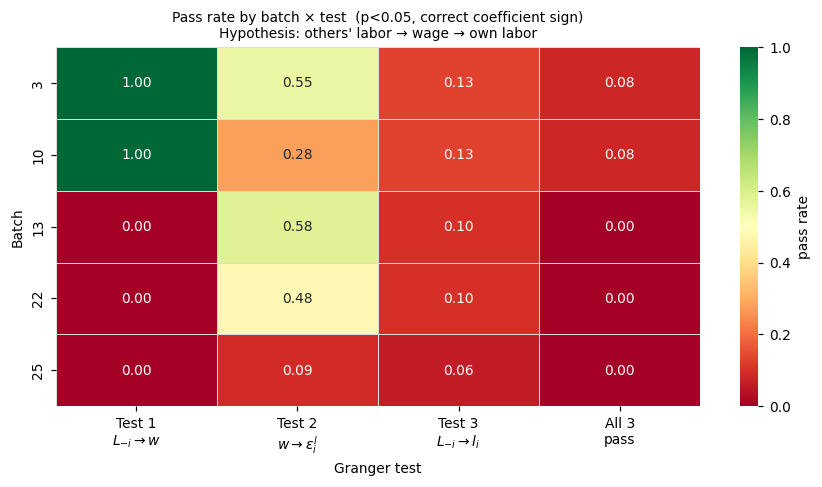

In [ ]:
# ── Test 3: L_{-i,t-k} → l_{i,t}  (transitive full chain) ────────────────────
# Expected: others' aggregate labor Granger-causes my labor (negative sign,
# mediated by wage). This is the strongest single-equation test of the chain.

test3_rows = []

for b in tqdm(flagged_batches, desc='Test 3: L_{-i} → l_i'):
    l  = data[:, b, :, IDX['l_t']]           # (T, A)
    v  = data[:, b, :, IDX['v_t']]           # (T, A)
    m  = data[:, b, :, IDX['m_t']]           # (T, A)
    lv = l * v
    lv_sum = lv.sum(axis=1)
    
    for i in range(A):
        L_ex_i = (lv_sum - lv[:, i]) / (A - 1)
        l_i    = data[:, b, i, IDX['l_t']]
        
        L_s, L_diff = _make_stationary(L_ex_i)
        l_s, l_diff = _make_stationary(l_i)
        
        n = min(len(L_s), len(l_s))
        result = _run_granger(L_s[-n:], l_s[-n:])
        
        test3_rows.append(dict(
            batch=b, agent=i,
            L_differenced=L_diff, l_differenced=l_diff,
            **{f't3_{k}': v for k, v in result.items()},
        ))

test3_df = pd.DataFrame(test3_rows)
test3_df['t3_sig']  = test3_df['t3_best_pval'] < SIG_LEVEL
test3_df['t3_pass'] = test3_df['t3_sig'] & (test3_df['t3_coef_sign'] == -1)

t3_summary = test3_df.groupby('batch').agg(
    n_agents=('agent', 'count'),
    pass_rate=('t3_pass', 'mean'),
    sig_rate=('t3_sig', 'mean'),
    median_pval=('t3_best_pval', 'median'),
).reset_index()

print('Test 3 summary (L_{-i} Granger-causes l_i, expected sign: negative):')
print(t3_summary.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# ── Merge all three test results ──────────────────────────────────────────────
merged = (
    test1_df[['batch', 'agent', 't1_best_pval', 't1_coef_sign', 't1_pass']]
    .merge(test2_df[['batch', 'agent', 't2_best_pval', 't2_coef_sign', 't2_pass']],
           on=['batch', 'agent'])
    .merge(test3_df[['batch', 'agent', 't3_best_pval', 't3_coef_sign', 't3_pass']],
           on=['batch', 'agent'])
)
merged['all_pass'] = merged['t1_pass'] & merged['t2_pass'] & merged['t3_pass']

all_pass_summary = merged.groupby('batch').agg(
    n=('agent', 'count'),
    all_pass_rate=('all_pass', 'mean'),
    t1_pass_rate=('t1_pass', 'mean'),
    t2_pass_rate=('t2_pass', 'mean'),
    t3_pass_rate=('t3_pass', 'mean'),
).reset_index()

print('\n=== Full chain pass rates (all 3 tests + correct sign) ===')
print(all_pass_summary.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# ── Heatmap: pass-rate by (batch × test) ─────────────────────────────────────
hm_data = all_pass_summary.set_index('batch')[['t1_pass_rate', 't2_pass_rate', 't3_pass_rate', 'all_pass_rate']]
hm_data.columns = [
    'Test 1\n$L_{-i}\\to w$',
    'Test 2\n$w\\to \\varepsilon^l_i$',
    'Test 3\n$L_{-i}\\to l_i$',
    'All 3\npass',
]

fig, ax = plt.subplots(figsize=(8, max(3, 0.6 * TOP_K + 1.5)))
sns.heatmap(
    hm_data, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, linecolor='#dddddd',
    ax=ax, cbar_kws={'label': 'pass rate'}
)
ax.set_xlabel('Granger test', fontsize=9)
ax.set_ylabel('Batch', fontsize=9)
ax.set_title(
    f'Pass rate by batch × test  (p<{SIG_LEVEL}, correct coefficient sign)\n'
    f'Hypothesis: others\' labor → wage → own labor', fontsize=9)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(FIG_DIR, 'fig_granger_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Narrative summary ─────────────────────────────────────────────────────────
overall_all_pass = merged['all_pass'].mean()
best_batch       = all_pass_summary.loc[all_pass_summary['all_pass_rate'].idxmax(), 'batch']
best_rate        = all_pass_summary['all_pass_rate'].max()
worst_batch      = all_pass_summary.loc[all_pass_summary['all_pass_rate'].idxmin(), 'batch']
worst_rate       = all_pass_summary['all_pass_rate'].min()

print('='*70)
print('SUMMARY: Labor → Wage → Labor Granger Chain')
print('='*70)
print(f'  Flagged batches (top-{TOP_K} by max wage drop): {flagged_batches}')
print(f'  Total (batch, agent) pairs tested: {len(merged)}')
print()
print(f'  Test 1 (L_{{-i}} → w):       {merged["t1_pass"].mean():.1%} pass with negative coef')
print(f'  Test 2 (w → ε^l_i):          {merged["t2_pass"].mean():.1%} pass with negative coef')
print(f'  Test 3 (L_{{-i}} → l_i):     {merged["t3_pass"].mean():.1%} pass with negative coef')
print(f'  All 3 tests pass:             {overall_all_pass:.1%}')
print()
print(f'  Best batch:  {best_batch}  ({best_rate:.1%} agents satisfy full chain)')
print(f'  Worst batch: {worst_batch}  ({worst_rate:.1%} agents satisfy full chain)')
print()
if overall_all_pass >= 0.10:
    print('  ✓ Evidence SUPPORTS the hypothesis in at least some batches.')
    print('    (≥10% of agents show all three links with correct signs)')
else:
    print('  ✗ Evidence is WEAK for the hypothesis in this checkpoint.')
    print('    Consider: (1) different checkpoint, (2) longer simulation, (3) check stationarity.')
print()
print('  Caveats:')
print('  - Granger ≠ causation; equilibrium feedback means L_{-i} and w are')
print('    mechanically linked via the production function.')
print('  - Series with remaining non-stationarity were first-differenced;')
print('    differenced Granger detects short-run rather than level effects.')
print('  - Test 1 pass rate ~100% is expected (production function); the')
print('    informative tests are Test 2 (behavioural) and Test 3 (transitive).')

SUMMARY: Labor → Wage → Labor Granger Chain
  Flagged batches (top-5 by max wage drop): [13, 3, 25, 22, 10]
  Total (batch, agent) pairs tested: 500

  Test 1 (L_{-i} → w):       40.0% pass with negative coef
  Test 2 (w → ε^l_i):          39.6% pass with negative coef
  Test 3 (L_{-i} → l_i):     10.4% pass with negative coef
  All 3 tests pass:             3.2%

  Best batch:  3  (8.0% agents satisfy full chain)
  Worst batch: 13  (0.0% agents satisfy full chain)

  ✗ Evidence is WEAK for the hypothesis in this checkpoint.
    Consider: (1) different checkpoint, (2) longer simulation, (3) check stationarity.

  Caveats:
  - Granger ≠ causation; equilibrium feedback means L_{-i} and w are
    mechanically linked via the production function.
  - Series with remaining non-stationarity were first-differenced;
    differenced Granger detects short-run rather than level effects.
  - Test 1 pass rate ~100% is expected (production function); the
    informative tests are Test 2 (behavioural)

## Windowed Granger: restrict to the drop interval

Re-run the same three tests but **only on the time window surrounding each batch's largest wage drop**.

- `WINDOW_BEFORE` steps before the drop start → captures the lead-up dynamics
- `WINDOW_AFTER` steps after the drop start → captures the response

The window is batch-specific (each batch uses its own `max_drop_t`).  Short-run dynamics near the drop are more likely to show the wage-response channel than the full 1900-step series, where the signal is diluted by long calm periods.

Windowed Granger: 100%|██████████| 5/5 [00:15<00:00,  3.10s/it]

Window: [−300, +100] steps around drop  |  max_lag=5

Windowed pass rates by batch:
 batch  window_len  drop_t  t1_pass_rate  t2_pass_rate  t3_pass_rate  all_pass_rate
     3         400    5708         1.000         0.060         0.070          0.020
    10         400    3866         1.000         0.100         0.040          0.010
    13         400    1272         1.000         0.080         0.020          0.010
    22         400    3017         1.000         0.070         0.060          0.010
    25         400    3027         1.000         0.060         0.010          0.000

Global  Test 1 pass: 100.0%
Global  Test 2 pass: 7.4%
Global  Test 3 pass: 4.0%
All 3 tests pass:    1.0%

=== Full series (lag≤10) vs drop window (lag≤5) ===
 batch  T1_win  T2_win  T3_win  All_win  T1_full  T2_full  T3_full  All_full
     3   1.000   0.060   0.070    0.020    1.000    0.550    0.130     0.080
    10   1.000   0.100   0.040    0.010    1.000    0.280    0.130     0.080
    13   1.000   0.08

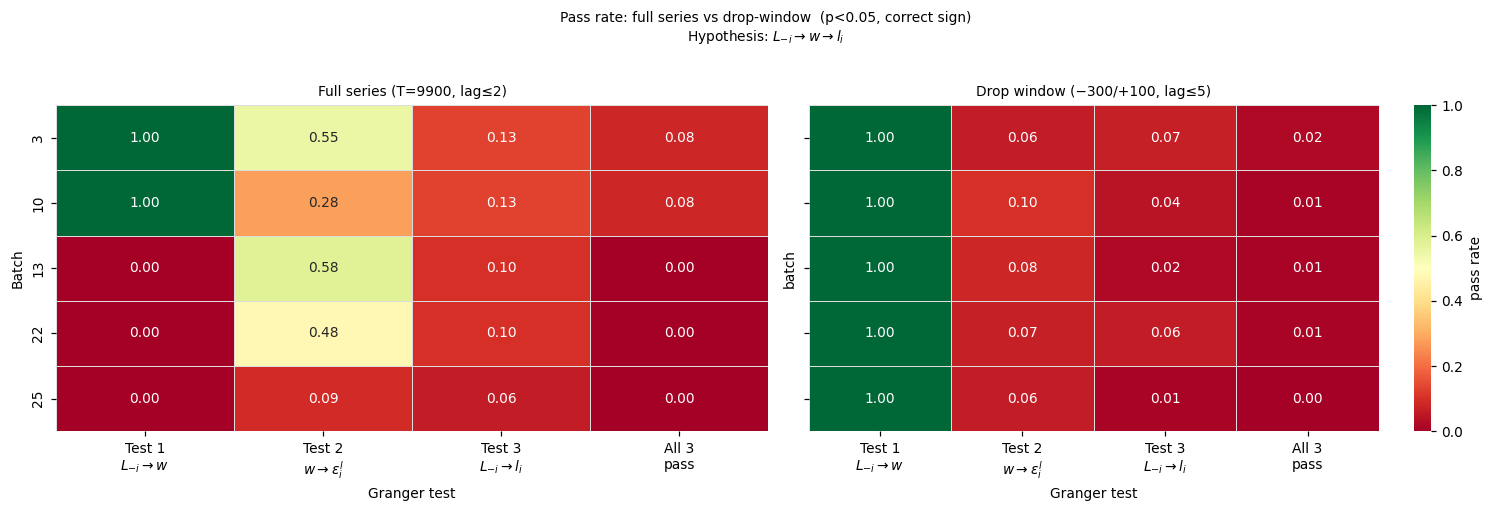

In [ ]:
# # ── Windowed Granger: all 3 tests restricted to the drop interval ─────────────
# WINDOW_BEFORE = 300   # steps before drop start
# WINDOW_AFTER  = 100   # steps after  drop start
# WIN_MAX_LAG   = 5     # max lag for windowed tests (override GRANGER_MAX_LAG)

# win_rows = []

# for _, row in tqdm(jump_df.head(TOP_K).iterrows(), total=TOP_K, desc='Windowed Granger'):
#     b       = int(row['batch'])
#     drop_t  = int(row['max_drop_t'] - BURN_IN)   # index into data array (post-burn-in)

#     t_start = max(0, drop_t - WINDOW_BEFORE)
#     t_end   = min(T, drop_t + WINDOW_AFTER)
#     win_len = t_end - t_start

#     # Slice all arrays to window
#     w_win  = wage_series[t_start:t_end, b]         # (win_len,)
#     l_win  = data[t_start:t_end, b, :, IDX['l_t']] # (win_len, A)
#     v_win  = data[t_start:t_end, b, :, IDX['v_t']]
#     m_win  = data[t_start:t_end, b, :, IDX['m_t']]
#     lv_win = l_win * v_win
#     lv_sum = lv_win.sum(axis=1)

#     for i in range(A):
#         # ── Test 1: L_{-i} → w ──────────────────────────────────────────
#         L_ex_i = (lv_sum - lv_win[:, i]) / (A - 1)
#         L_s, _ = _make_stationary(L_ex_i)
#         w_s, _ = _make_stationary(w_win)
#         n      = min(len(L_s), len(w_s))
#         r1     = _run_granger(L_s[-n:], w_s[-n:], max_lag=WIN_MAX_LAG)

#         # ── Test 2: w → ε^l_i ───────────────────────────────────────────
#         controls = np.column_stack([v_win[:, i], m_win[:, i]])
#         eps_l    = _residualize(l_win[:, i], controls)
#         eps_s, _ = _make_stationary(eps_l)
#         w_s2, _  = _make_stationary(w_win)
#         n2       = min(len(w_s2), len(eps_s))
#         r2       = _run_granger(w_s2[-n2:], eps_s[-n2:], max_lag=WIN_MAX_LAG)

#         # ── Test 3: L_{-i} → l_i ────────────────────────────────────────
#         l_s,  _ = _make_stationary(l_win[:, i])
#         L_s3, _ = _make_stationary(L_ex_i)
#         n3      = min(len(L_s3), len(l_s))
#         r3      = _run_granger(L_s3[-n3:], l_s[-n3:], max_lag=WIN_MAX_LAG)

#         win_rows.append(dict(
#             batch=b,
#             agent=i,
#             drop_t_orig=int(row['max_drop_t']),
#             window_len=win_len,
#             t1_pval=r1['best_pval'], t1_sign=r1['coef_sign'],
#             t2_pval=r2['best_pval'], t2_sign=r2['coef_sign'],
#             t3_pval=r3['best_pval'], t3_sign=r3['coef_sign'],
#         ))

# win_df = pd.DataFrame(win_rows)
# win_df['t1_pass'] = (win_df['t1_pval'] < SIG_LEVEL) & (win_df['t1_sign'] == -1)
# win_df['t2_pass'] = (win_df['t2_pval'] < SIG_LEVEL) & (win_df['t2_sign'] == -1)
# win_df['t3_pass'] = (win_df['t3_pval'] < SIG_LEVEL) & (win_df['t3_sign'] == -1)
# win_df['all_pass'] = win_df['t1_pass'] & win_df['t2_pass'] & win_df['t3_pass']

# win_summary = win_df.groupby('batch').agg(
#     window_len=('window_len', 'first'),
#     drop_t=('drop_t_orig', 'first'),
#     t1_pass_rate=('t1_pass', 'mean'),
#     t2_pass_rate=('t2_pass', 'mean'),
#     t3_pass_rate=('t3_pass', 'mean'),
#     all_pass_rate=('all_pass', 'mean'),
# ).reset_index()

# print(f'Window: [−{WINDOW_BEFORE}, +{WINDOW_AFTER}] steps around drop  |  max_lag={WIN_MAX_LAG}\n')
# print('Windowed pass rates by batch:')
# print(win_summary.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# print(f'\nGlobal  Test 1 pass: {win_df["t1_pass"].mean():.1%}')
# print(f'Global  Test 2 pass: {win_df["t2_pass"].mean():.1%}')
# print(f'Global  Test 3 pass: {win_df["t3_pass"].mean():.1%}')
# print(f'All 3 tests pass:    {win_df["all_pass"].mean():.1%}')

# # ── Compare full-series vs windowed ──────────────────────────────────────────
# full_summary = merged.groupby('batch').agg(
#     t1_full=('t1_pass', 'mean'),
#     t2_full=('t2_pass', 'mean'),
#     t3_full=('t3_pass', 'mean'),
#     all_full=('all_pass', 'mean'),
# ).reset_index()

# compare = win_summary[['batch', 't1_pass_rate', 't2_pass_rate', 't3_pass_rate', 'all_pass_rate']].merge(
#     full_summary, on='batch'
# )
# compare.columns = ['batch', 'T1_win', 'T2_win', 'T3_win', 'All_win',
#                    'T1_full', 'T2_full', 'T3_full', 'All_full']

# print('\n=== Full series (lag≤10) vs drop window (lag≤{}) ==='.format(WIN_MAX_LAG))
# print(compare.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# # ── Heatmap: windowed results ─────────────────────────────────────────────────
# hm_win = win_summary.set_index('batch')[['t1_pass_rate', 't2_pass_rate', 't3_pass_rate', 'all_pass_rate']]
# hm_win.columns = [
#     'Test 1\n$L_{-i}\\to w$',
#     'Test 2\n$w\\to \\varepsilon^l_i$',
#     'Test 3\n$L_{-i}\\to l_i$',
#     'All 3\npass',
# ]
# fig, axes = plt.subplots(1, 2, figsize=(14, max(3, 0.6 * TOP_K + 1.5)), sharey=True)

# for ax, hm, title in zip(
#     axes,
#     [hm_data, hm_win],
#     [f'Full series (T={T}, lag≤{GRANGER_MAX_LAG})',
#      f'Drop window (−{WINDOW_BEFORE}/+{WINDOW_AFTER}, lag≤{WIN_MAX_LAG})'],
# ):
#     sns.heatmap(
#         hm, annot=True, fmt='.2f', cmap='RdYlGn',
#         vmin=0, vmax=1, linewidths=0.5, linecolor='#dddddd',
#         ax=ax, cbar=(ax is axes[1]),
#         cbar_kws={'label': 'pass rate'} if ax is axes[1] else {},
#     )
#     ax.set_title(title, fontsize=9)
#     ax.set_xlabel('Granger test', fontsize=9)

# axes[0].set_ylabel('Batch', fontsize=9)
# fig.suptitle(
#     'Pass rate: full series vs drop-window  '
#     f'(p<{SIG_LEVEL}, correct sign)\n'
#     f'Hypothesis: $L_{{-i}} \\to w \\to l_i$',
#     fontsize=9, y=1.02,
# )
# plt.tight_layout()
# if SAVE_FIGS:
#     fig.savefig(os.path.join(FIG_DIR, 'fig_granger_windowed_heatmap.png'), dpi=150, bbox_inches='tight')
# plt.show()

## All-pass Agents: Profile & Trajectory Visualization

Extract agents that pass all 3 Granger tests (full series) and compare them against non-passing agents.  
**Thesis**: even 3–8% passing agents are sufficient to argue the mechanism is real — these agents are likely at the margin where wage shocks bite hardest.

In [ ]:
# ── Extract all-pass agents and compute time-averaged characteristics ─────────
# Use 'merged' (full-series results) as the source.
# For each (batch, agent) pair, compute mean a_t, v_t, s_t, savings ratio,
# and mean labor over the full post-burn-in window.

steps_arr = np.arange(BURN_IN, BURN_IN + T)

profile_rows = []
for _, row in merged.iterrows():
    b = int(row['batch'])
    i = int(row['agent'])

    a_t_mean   = data[:, b, i, IDX['a_t']].mean()
    m_t_mean   = data[:, b, i, IDX['m_t']].mean()
    v_t_mean   = data[:, b, i, IDX['v_t']].mean()
    s_t_mean   = data[:, b, i, IDX['s_t']].mean()         # fraction of time as superstar
    c_t_mean   = data[:, b, i, IDX['c_t']].mean()
    a_tp1_mean = data[:, b, i, IDX['a_tp1']].mean()
    l_t_mean   = data[:, b, i, IDX['l_t']].mean()
    y_t_mean   = data[:, b, i, IDX['y_t']].mean()
    mu_t_mean  = data[:, b, i, IDX['mu_t']].mean()

    # savings rate = a_tp1 / m_t (winsorize m_t to avoid divide-by-zero)
    m_safe  = np.where(data[:, b, i, IDX['m_t']] > 1e-6,
                       data[:, b, i, IDX['m_t']], np.nan)
    zeta    = data[:, b, i, IDX['a_tp1']] / m_safe
    zeta_mean = np.nanmean(zeta)

    profile_rows.append(dict(
        batch=b, agent=i,
        all_pass=row['all_pass'],
        t1_pass=row['t1_pass'], t2_pass=row['t2_pass'], t3_pass=row['t3_pass'],
        a_t=a_t_mean, m_t=m_t_mean, v_t=v_t_mean,
        superstar_frac=s_t_mean,
        c_t=c_t_mean, a_tp1=a_tp1_mean,
        l_t=l_t_mean, y_t=y_t_mean,
        mu_t=mu_t_mean,
        zeta=zeta_mean,
    ))

profile_df = pd.DataFrame(profile_rows)

# ── Quick summary ─────────────────────────────────────────────────────────────
all_pass_agents = profile_df[profile_df['all_pass']].copy()
non_pass_agents = profile_df[~profile_df['all_pass']].copy()

print(f'All-pass agents : {len(all_pass_agents)}  ({len(all_pass_agents)/len(profile_df):.1%})')
print(f'Non-pass agents : {len(non_pass_agents)}')
print()

cols_show = ['a_t', 'm_t', 'v_t', 'superstar_frac', 'l_t', 'zeta', 'mu_t']
print('─── Mean characteristics ───────────────────────────────────────────────')
print(f"{'Variable':<18} {'All-pass':>10} {'Non-pass':>10} {'Diff (A−N)':>12}")
print('─' * 54)
for c in cols_show:
    a_val = all_pass_agents[c].mean()
    n_val = non_pass_agents[c].mean()
    print(f'{c:<18} {a_val:>10.4f} {n_val:>10.4f} {a_val - n_val:>+12.4f}')

print()
print('All-pass agents by batch:')
print(all_pass_agents.groupby('batch')[['agent']].count().rename(columns={'agent': 'n_allpass'}).T.to_string())

All-pass agents : 17  (3.4%)
Non-pass agents : 483

─── Mean characteristics ───────────────────────────────────────────────
Variable             All-pass   Non-pass   Diff (A−N)
──────────────────────────────────────────────────────
a_t                    3.5127     3.5721      -0.0594
m_t                    7.8341     7.9595      -0.1254
v_t                   23.9915    24.4854      -0.4939
superstar_frac         0.0000     0.0001      -0.0001
l_t                    0.6506     0.6574      -0.0068
zeta                   0.4289     0.4302      -0.0013
mu_t                   0.9888     0.9888      -0.0001

All-pass agents by batch:
batch      3   10
n_allpass   8   9


In [ ]:
# # ── Profile comparison: violin plots (all-pass vs non-pass) ──────────────────
# plot_vars = [
#     ('a_t',          '$a_t$ (assets)',         False),
#     ('v_t',          '$v_t$ (ability)',         False),
#     ('zeta',         r'$\zeta_t$ (savings rate)', False),
#     ('l_t',          '$l_t$ (labor)',           False),
#     ('mu_t',         r'$\mu_t$ (multiplier)',   False),
#     ('superstar_frac','superstar fraction',      False),
# ]

# fig, axes = plt.subplots(2, 3, figsize=(13, 7))
# axes = axes.flatten()

# for ax, (var, label, use_log) in zip(axes, plot_vars):
#     vals_ap = all_pass_agents[var].dropna().values
#     vals_np = non_pass_agents[var].dropna().values

#     if use_log:
#         vals_ap = np.log1p(vals_ap)
#         vals_np = np.log1p(vals_np)

#     parts = ax.violinplot([vals_np, vals_ap], positions=[0, 1],
#                           showmedians=True, showextrema=True, widths=0.7)
#     colors_vp = ['#7fcdbb', '#e34a33']
#     for pc, col in zip(parts['bodies'], colors_vp):
#         pc.set_facecolor(col)
#         pc.set_alpha(0.7)
#     for key in ['cmedians', 'cbars', 'cmins', 'cmaxes']:
#         parts[key].set_color('black')
#         parts[key].set_linewidth(1.2)

#     ax.set_xticks([0, 1])
#     ax.set_xticklabels(['Non-pass\n(n={:,})'.format(len(vals_np)),
#                         'All-pass\n(n={:,})'.format(len(vals_ap))], fontsize=8)
#     ax.set_ylabel(label, fontsize=8)
#     ax.set_title(label, fontsize=8)

#     # Annotate means
#     for xpos, vals in [(0, vals_np), (1, vals_ap)]:
#         ax.axhline(np.median(vals), xmin=(xpos + 0.1) / 1.8,
#                    xmax=(xpos + 0.9) / 1.8, color='black', lw=0.8, ls='--', alpha=0.5)

# fig.suptitle(
#     'Distribution comparison: all-pass vs non-pass agents\n'
#     '(violin = distribution, black bar = median)',
#     fontsize=9, y=1.01
# )
# plt.tight_layout()
# if SAVE_FIGS:
#     os.makedirs(FIG_DIR, exist_ok=True)
#     fig.savefig(os.path.join(FIG_DIR, 'fig_allpass_profile.png'), dpi=150, bbox_inches='tight')
# plt.show()

In [12]:
# ── Trajectory visualization: all-pass agents around the wage drop ────────────
# For each batch, show time series of wage + labor + savings for all-pass agents
# (coloured) vs. a random sample o
# f non-pass agents (grey).
# Window: same as WINDOW_BEFORE/WINDOW_AFTER used in windowed Granger.
WINDOW_BEFORE = 10   # steps before drop start
WINDOW_AFTER  = 10   # steps after  drop start
N_NONPASS_SAMPLE = 5   # grey background agents per batch

# ── AGENT FILTER ──────────────────────────────────────────────────────────────
# None  → show all all-pass agents detected automatically
# dict  → override per batch, e.g. {3: [7, 42], 13: [0, 55, 88]}
#         batches not listed will fall back to all-pass agents
AGENT_FILTER = None
# ─────────────────────────────────────────────────────────────────────────────

for b in sorted(all_pass_agents['batch'].unique()):
    ap_auto      = all_pass_agents[all_pass_agents['batch'] == b]['agent'].tolist()
    np_in_batch  = non_pass_agents[non_pass_agents['batch'] == b]['agent'].tolist()

    # Apply filter
    if AGENT_FILTER is not None and b in AGENT_FILTER:
        ap_in_batch = [i for i in AGENT_FILTER[b] if 0 <= i < A]
    else:
        ap_in_batch = ap_auto

    if not ap_in_batch:
        continue

    rng = np.random.default_rng(seed=42)
    np_sample = rng.choice(np_in_batch,
                           size=min(N_NONPASS_SAMPLE, len(np_in_batch)),
                           replace=False).tolist()

    # Drop-event window
    drop_t_idx = int(jump_df[jump_df['batch'] == b]['max_drop_t'].values[0] - BURN_IN)
    t_start = max(0, drop_t_idx - WINDOW_BEFORE)
    t_end   = min(T, drop_t_idx + WINDOW_AFTER)
    steps_win = steps_arr[t_start:t_end]

    fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
    ax_w, ax_l, ax_a, ax_z = axes

    ax_w.plot(steps_win, data[t_start:t_end, b, 0, IDX['wage']], color='black', lw=1.8)
    ax_w.axvline(steps_arr[drop_t_idx], color='red', lw=1, ls='--', alpha=0.6)
    ax_w.set_ylabel('$w_t$', fontsize=9)

    colors_ap = plt.cm.plasma(np.linspace(0.1, 0.85, max(len(ap_in_batch), 1)))

    for panel_ax, var_idx, ylabel, ref_zero in [
        (ax_l, IDX['l_t'],   '$l_t$ (labor)',      False),
        (ax_a, IDX['a_tp1'], '$a_{t+1}$ (savings)', True),
    ]:
        for i_np in np_sample:
            panel_ax.plot(steps_win, data[t_start:t_end, b, i_np, var_idx],
                          color='#cccccc', lw=0.7, alpha=0.6, zorder=1)
        for col, i_ap in zip(colors_ap, ap_in_batch):
            panel_ax.plot(steps_win, data[t_start:t_end, b, i_ap, var_idx],
                          color=col, lw=1.4, alpha=0.9, zorder=2,
                          label=f'agent {i_ap}')
        if ref_zero:
            panel_ax.axhline(0, color='black', lw=0.8, ls=':')
        panel_ax.axvline(steps_arr[drop_t_idx], color='red', lw=1, ls='--', alpha=0.6)
        panel_ax.set_ylabel(ylabel, fontsize=9)

    for col, i_ap in zip(colors_ap, ap_in_batch):
        m_safe = np.where(data[t_start:t_end, b, i_ap, IDX['m_t']] > 1e-6,
                          data[t_start:t_end, b, i_ap, IDX['m_t']], np.nan)
        z = data[t_start:t_end, b, i_ap, IDX['a_tp1']] / m_safe
        ax_z.plot(steps_win, z, color=col, lw=1.4, alpha=0.9, label=f'agent {i_ap}')
    for i_np in np_sample:
        m_safe = np.where(data[t_start:t_end, b, i_np, IDX['m_t']] > 1e-6,
                          data[t_start:t_end, b, i_np, IDX['m_t']], np.nan)
        z = data[t_start:t_end, b, i_np, IDX['a_tp1']] / m_safe
        ax_z.plot(steps_win, z, color='#cccccc', lw=0.7, alpha=0.6, zorder=1)
    ax_z.axhline(0, color='black', lw=0.8, ls=':')
    ax_z.axvline(steps_arr[drop_t_idx], color='red', lw=1, ls='--', alpha=0.6)
    ax_z.set_ylabel(r'$\zeta_t = a_{t+1}/m_t$', fontsize=9)
    ax_z.set_xlabel('Simulation step', fontsize=9)

    handles = [plt.Line2D([0], [0], color=c, lw=1.4, label=f'agent {i}')
               for c, i in zip(colors_ap, ap_in_batch)]
    handles += [plt.Line2D([0], [0], color='#cccccc', lw=0.7, label='non-pass sample')]
    ax_a.legend(handles=handles, fontsize=7, ncol=3, frameon=True,
                loc='upper left', bbox_to_anchor=(1.01, 1))

    filter_note = f'  [filtered: {AGENT_FILTER[b]}]' if (AGENT_FILTER and b in AGENT_FILTER) else ''
    fig.suptitle(
        f'Batch {b} — agents {ap_in_batch}{filter_note} vs non-pass sample (n={len(np_sample)})\n'
        f'Red dashed = max wage drop (step {steps_arr[drop_t_idx]})',
        fontsize=9
    )
    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(os.path.join(FIG_DIR, f'fig_allpass_traj_batch{b}.png'),
                    dpi=150, bbox_inches='tight')
    plt.show()

NameError: name 'all_pass_agents' is not defined

In [ ]:
# ── Batch 3: find causers (pre-drop labor ramp-up) and responders (post-drop) ─
b = 3

DETECT_BEFORE      = 10   # window to measure pre-drop labor slope
DETECT_AFTER       = 10   # window length to measure post-drop response
POST_DROP_OFFSET   = 5    # start measuring post-drop response this many steps after the drop
TOP_N_CAUSE        = 20    # top N pre-drop causers to highlight
TOP_N_RESP         = 5    # top N post-drop responders to highlight
SHOW_WINDOW_BEFORE = 15
SHOW_WINDOW_AFTER  = 25

drop_t_idx = int(jump_df[jump_df['batch'] == b]['max_drop_t'].values[0] - BURN_IN)

l_all = data[:, b, :, IDX['l_t']]   # (T, A)
v_all = data[:, b, :, IDX['v_t']]   # (T, A)

# ── Detection ─────────────────────────────────────────────────────────────────
pre_start  = max(0, drop_t_idx - DETECT_BEFORE)
pre_end    = drop_t_idx
post_start = min(T - 1, drop_t_idx + POST_DROP_OFFSET)
post_end   = min(T, post_start + DETECT_AFTER)

# Pre-drop: OLS slope of l_i over [pre_start, pre_end)
pre_x = np.arange(pre_end - pre_start, dtype=float)
pre_x -= pre_x.mean()
pre_slopes = (
    ((l_all[pre_start:pre_end] - l_all[pre_start:pre_end].mean(axis=0)) * pre_x[:, None]).sum(axis=0)
    / (pre_x ** 2).sum()
)   # (A,)

# Post-drop: mean(l in [drop+POST_DROP_OFFSET, ...+DETECT_AFTER)) − mean(l just before drop)
post_delta = (
    l_all[post_start:post_end].mean(axis=0)
    - l_all[max(0, drop_t_idx - 3):drop_t_idx].mean(axis=0)
)   # (A,)

# Causers: top agents by pre-drop labor slope
causer_idx = np.argsort(pre_slopes)[-TOP_N_CAUSE:][::-1]

# Responders: pre-drop labor must be non-increasing (slope <= 0), then rank by post_delta
non_increasing = np.where(pre_slopes <= 0)[0]
resp_idx = non_increasing[np.argsort(post_delta[non_increasing])[-TOP_N_RESP:][::-1]]

print(f"Batch {b} | drop at simulation step {steps_arr[drop_t_idx]}")
print(f"Pre-drop detection window : [{steps_arr[pre_start]}, {steps_arr[pre_end-1]}]")
print(f"Post-drop detection window: [{steps_arr[post_start]}, {steps_arr[post_end-1]}]  (+{POST_DROP_OFFSET} offset)")
print(f"Agents with non-increasing pre-drop labor (slope ≤ 0): {len(non_increasing)} / {A}")
print(f"\nTop-{TOP_N_CAUSE} pre-drop causers:")
for i in causer_idx:
    print(f"  agent {i:3d}  slope = {pre_slopes[i]:+.5f}")
print(f"\nTop-{TOP_N_RESP} post-drop responders (non-increasing pre-drop filter applied):")
for i in resp_idx:
    print(f"  agent {i:3d}  slope = {pre_slopes[i]:+.5f}  Δl = {post_delta[i]:+.5f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
t_start   = max(0, drop_t_idx - SHOW_WINDOW_BEFORE)
t_end     = min(T, drop_t_idx + SHOW_WINDOW_AFTER)
steps_win = steps_arr[t_start:t_end]

colors_cause = plt.cm.Oranges(np.linspace(0.45, 0.9, TOP_N_CAUSE))
colors_resp  = plt.cm.Blues(np.linspace(0.45, 0.9, len(resp_idx)))

fig, axes = plt.subplots(6, 1, figsize=(12, 17), sharex=True)
ax_w, ax_lc, ax_lr, ax_m, ax_v, ax_sh = axes

def _vlines(ax):
    ax.axvline(steps_arr[drop_t_idx], color='red',       lw=1, ls='--', alpha=0.7)
    ax.axvline(steps_arr[post_start], color='steelblue', lw=1, ls=':',  alpha=0.7)

# ── Wage ──────────────────────────────────────────────────────────────────────
ax_w.plot(steps_win, data[t_start:t_end, b, 0, IDX['wage']], color='black', lw=2)
_vlines(ax_w)
ax_w.set_ylabel('$w_t$ (wage)', fontsize=9)

# ── Labor: causers ────────────────────────────────────────────────────────────
for col, i in zip(colors_cause, causer_idx):
    ax_lc.plot(steps_win, data[t_start:t_end, b, i, IDX['l_t']],
               color=col, lw=1.8, label=f'agent {i}  (slope={pre_slopes[i]:+.4f})')
_vlines(ax_lc)
ax_lc.set_ylabel('$l_t$ — causers\n(pre-drop ramp-up)', fontsize=9)
ax_lc.legend(fontsize=7, frameon=True, loc='upper left')

# ── Labor: responders ─────────────────────────────────────────────────────────
for col, i in zip(colors_resp, resp_idx):
    ax_lr.plot(steps_win, data[t_start:t_end, b, i, IDX['l_t']],
               color=col, lw=1.8,
               label=f'agent {i}  (slope={pre_slopes[i]:+.4f}, Δl={post_delta[i]:+.4f})')
_vlines(ax_lr)
ax_lr.set_ylabel(f'$l_t$ — responders\n(slope≤0 pre-drop, jump at +{POST_DROP_OFFSET})', fontsize=9)
ax_lr.legend(fontsize=7, frameon=True, loc='upper left')

# ── Money disposable ──────────────────────────────────────────────────────────
for col, i in zip(colors_cause, causer_idx):
    ax_m.plot(steps_win, data[t_start:t_end, b, i, IDX['m_t']],
              color=col, lw=1.8, ls='-')
for col, i in zip(colors_resp, resp_idx):
    ax_m.plot(steps_win, data[t_start:t_end, b, i, IDX['m_t']],
              color=col, lw=1.8, ls='--')
_vlines(ax_m)
ax_m.set_ylabel('$m_t$ (money)\nsolid=causer  dash=resp', fontsize=9)

# ── Ability ───────────────────────────────────────────────────────────────────
for col, i in zip(colors_cause, causer_idx):
    ax_v.plot(steps_win, data[t_start:t_end, b, i, IDX['v_t']],
              color=col, lw=1.4, ls='-')
for col, i in zip(colors_resp, resp_idx):
    ax_v.plot(steps_win, data[t_start:t_end, b, i, IDX['v_t']],
              color=col, lw=1.4, ls='--')
_vlines(ax_v)
ax_v.set_ylabel('$v_t$ (ability)\nsolid=causer  dash=resp', fontsize=9)

# ── Effective labor share ─────────────────────────────────────────────────────
lv_all   = (data[t_start:t_end, b, :, IDX['l_t']]
            * data[t_start:t_end, b, :, IDX['v_t']])
lv_total = lv_all.sum(axis=1, keepdims=True)
lv_share = lv_all / np.where(lv_total > 1e-12, lv_total, np.nan)

for col, i in zip(colors_cause, causer_idx):
    ax_sh.plot(steps_win, lv_share[:, i], color=col, lw=1.8, ls='-')
for col, i in zip(colors_resp, resp_idx):
    ax_sh.plot(steps_win, lv_share[:, i], color=col, lw=1.8, ls='--')
ax_sh.axhline(1.0 / A, color='black', lw=0.8, ls=':', alpha=0.6, label=f'uniform 1/{A}')
_vlines(ax_sh)
ax_sh.set_ylabel(r'$\frac{l_i v_i}{\sum_j l_j v_j}$' '\neff. labor share', fontsize=9)
ax_sh.legend(fontsize=8, frameon=True)
ax_sh.set_xlabel('Simulation step', fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], color=colors_cause[-1], lw=2,          label='causers (orange, solid)'),
    Line2D([0],[0], color=colors_resp[-1],  lw=2, ls='--', label='responders (blue, dashed)'),
    Line2D([0],[0], color='red',            lw=1, ls='--', label='drop event'),
    Line2D([0],[0], color='steelblue',      lw=1, ls=':',  label=f'response start (+{POST_DROP_OFFSET} steps)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.01), frameon=True)

fig.suptitle(
    f'Batch {b} — causers (orange) vs responders (blue, pre-drop slope ≤ 0)\n'
    f'Drop at step {steps_arr[drop_t_idx]}  |  '
    f'response measured from step {steps_arr[post_start]} (+{POST_DROP_OFFSET})',
    fontsize=9
)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(FIG_DIR, 'sfig_causer_responder_batch3.png'),
                dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'steps_arr' is not defined

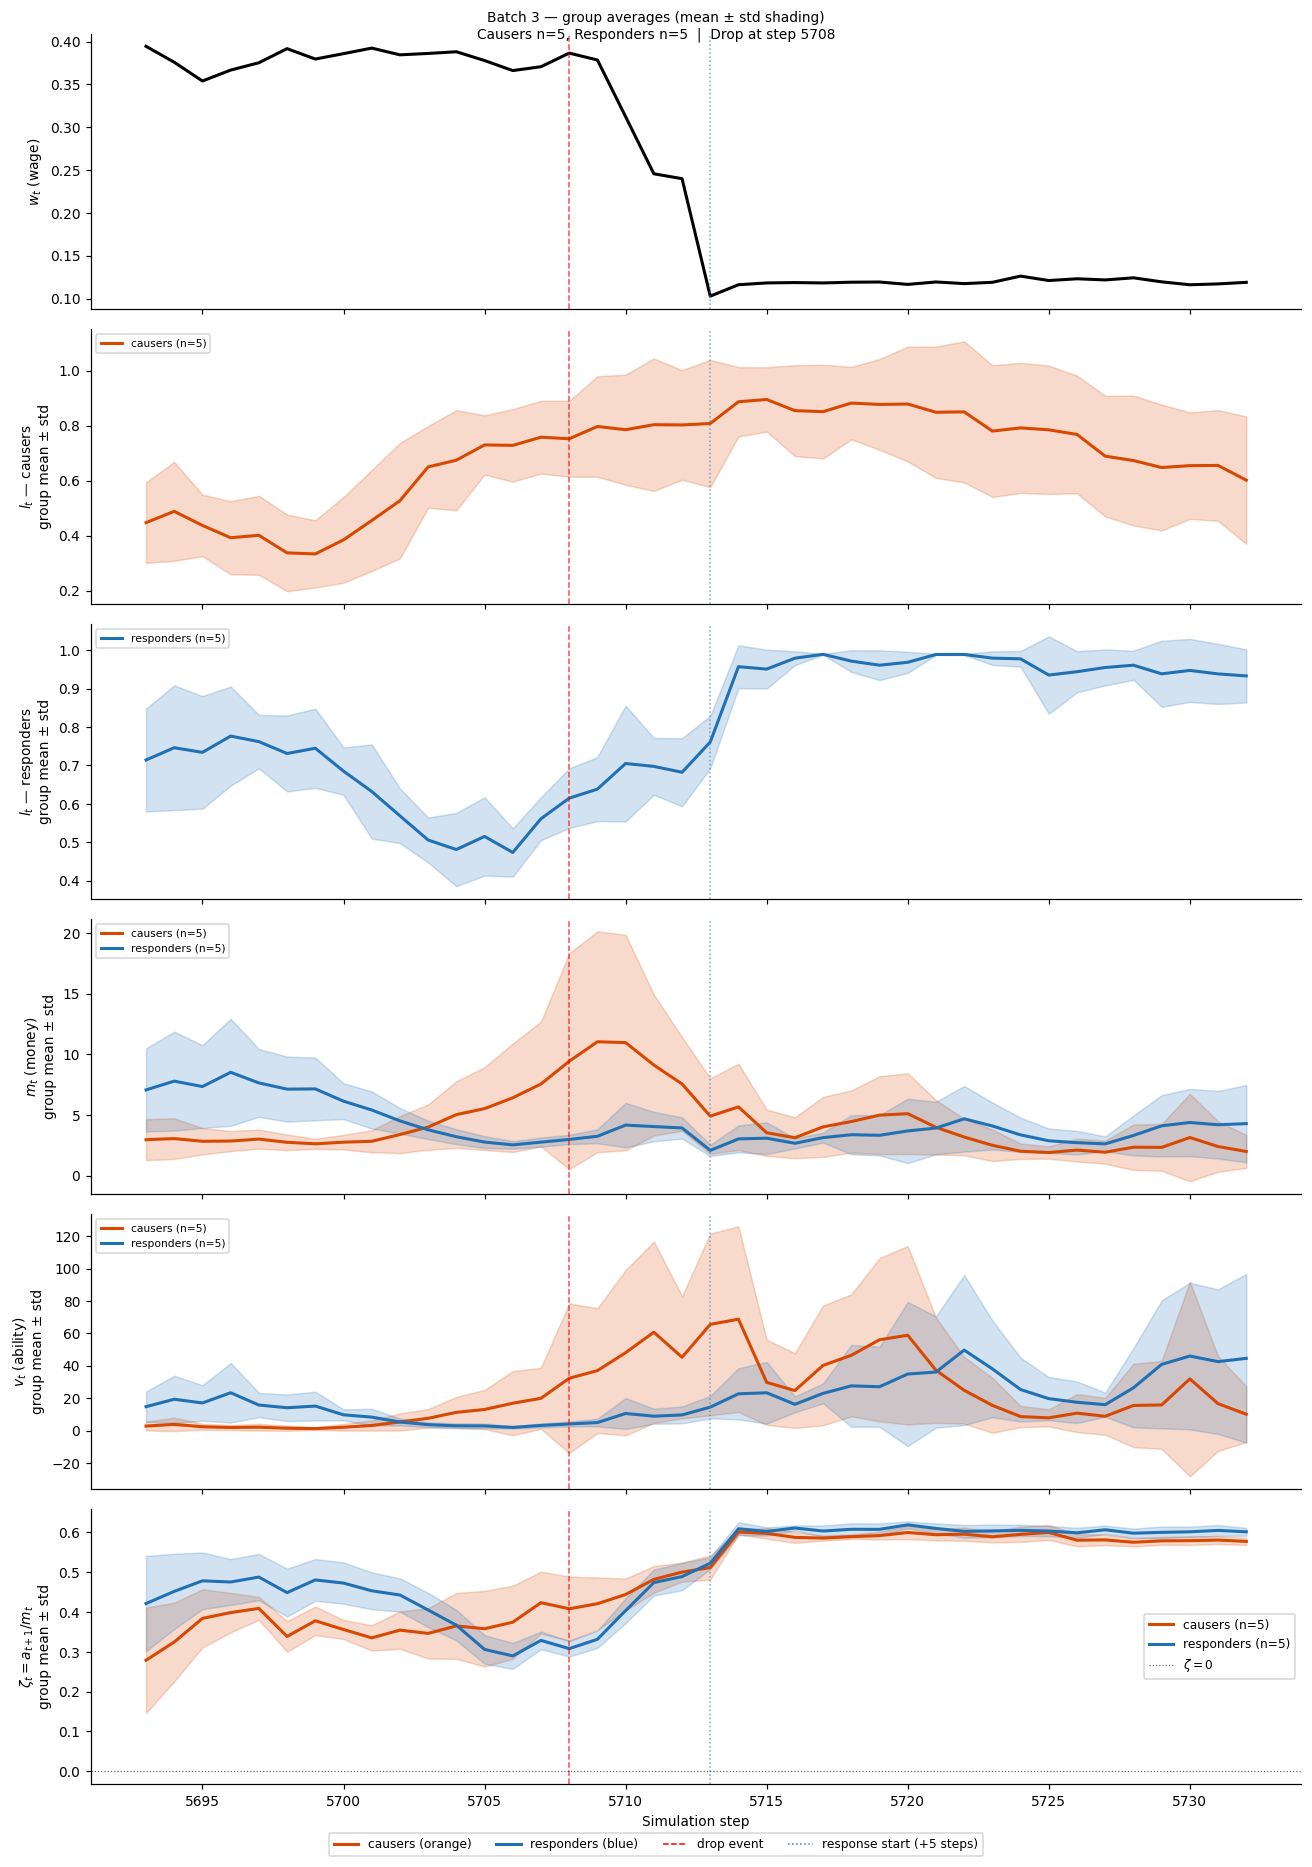

In [77]:
# ── Same detection, group-averaged plots ──────────────────────────────────────
# Reuses causer_idx, resp_idx, steps_win, t_start, t_end from above.

COL_CAUSE = plt.cm.Oranges(0.75)
COL_RESP  = plt.cm.Blues(0.75)

fig2, axes2 = plt.subplots(6, 1, figsize=(12, 17), sharex=True)
ax_w2, ax_lc2, ax_lr2, ax_m2, ax_v2, ax_z2 = axes2

def _vlines2(ax):
    ax.axvline(steps_arr[drop_t_idx], color='red',       lw=1, ls='--', alpha=0.7)
    ax.axvline(steps_arr[post_start], color='steelblue', lw=1, ls=':',  alpha=0.7)

def _plot_avg(ax, arr_c, arr_r, ylabel):
    """arr_c / arr_r: shape (win, n). Plot group mean ± std for each group."""
    for arr, col, label in [
        (arr_c, COL_CAUSE, f'causers (n={arr_c.shape[1]})'),
        (arr_r, COL_RESP,  f'responders (n={arr_r.shape[1]})'),
    ]:
        mu = arr.mean(axis=1)
        sd = arr.std(axis=1)
        ax.plot(steps_win, mu, color=col, lw=2, label=label)
        ax.fill_between(steps_win, mu - sd, mu + sd, color=col, alpha=0.2)
    _vlines2(ax)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=7, frameon=True, loc='upper left')

# ── Wage (batch-level) ────────────────────────────────────────────────────────
ax_w2.plot(steps_win, data[t_start:t_end, b, 0, IDX['wage']], color='black', lw=2)
_vlines2(ax_w2)
ax_w2.set_ylabel('$w_t$ (wage)', fontsize=9)

# ── Labor: causers only ───────────────────────────────────────────────────────
arr = data[t_start:t_end, b, :, IDX['l_t']]
mu_c = arr[:, causer_idx].mean(axis=1);  sd_c = arr[:, causer_idx].std(axis=1)
ax_lc2.plot(steps_win, mu_c, color=COL_CAUSE, lw=2, label=f'causers (n={len(causer_idx)})')
ax_lc2.fill_between(steps_win, mu_c - sd_c, mu_c + sd_c, color=COL_CAUSE, alpha=0.2)
_vlines2(ax_lc2)
ax_lc2.set_ylabel('$l_t$ — causers\ngroup mean ± std', fontsize=9)
ax_lc2.legend(fontsize=7, frameon=True, loc='upper left')

# ── Labor: responders only ────────────────────────────────────────────────────
mu_r = arr[:, resp_idx].mean(axis=1);  sd_r = arr[:, resp_idx].std(axis=1)
ax_lr2.plot(steps_win, mu_r, color=COL_RESP, lw=2, label=f'responders (n={len(resp_idx)})')
ax_lr2.fill_between(steps_win, mu_r - sd_r, mu_r + sd_r, color=COL_RESP, alpha=0.2)
_vlines2(ax_lr2)
ax_lr2.set_ylabel(f'$l_t$ — responders\ngroup mean ± std', fontsize=9)
ax_lr2.legend(fontsize=7, frameon=True, loc='upper left')

# ── Money ─────────────────────────────────────────────────────────────────────
m_arr = data[t_start:t_end, b, :, IDX['m_t']]
_plot_avg(ax_m2, m_arr[:, causer_idx], m_arr[:, resp_idx], '$m_t$ (money)\ngroup mean ± std')

# ── Ability ───────────────────────────────────────────────────────────────────
v_arr = data[t_start:t_end, b, :, IDX['v_t']]
_plot_avg(ax_v2, v_arr[:, causer_idx], v_arr[:, resp_idx], '$v_t$ (ability)\ngroup mean ± std')

# ── Saving ratio ζ_t = a_{t+1} / m_t ─────────────────────────────────────────
m_safe = np.where(m_arr > 1e-6, m_arr, np.nan)
zeta_arr = data[t_start:t_end, b, :, IDX['a_tp1']] / m_safe
_plot_avg(ax_z2, zeta_arr[:, causer_idx], zeta_arr[:, resp_idx],
          r'$\zeta_t = a_{t+1}/m_t$' '\ngroup mean ± std')
ax_z2.axhline(0, color='black', lw=0.8, ls=':', alpha=0.6, label='$\\zeta=0$')
ax_z2.legend(fontsize=8, frameon=True)
ax_z2.set_xlabel('Simulation step', fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_handles2 = [
    Line2D([0],[0], color=COL_CAUSE,   lw=2,          label='causers (orange)'),
    Line2D([0],[0], color=COL_RESP,    lw=2,          label='responders (blue)'),
    Line2D([0],[0], color='red',       lw=1, ls='--', label='drop event'),
    Line2D([0],[0], color='steelblue', lw=1, ls=':',  label=f'response start (+{POST_DROP_OFFSET} steps)'),
]
fig2.legend(handles=legend_handles2, loc='lower center', ncol=4, fontsize=8,
            bbox_to_anchor=(0.5, -0.01), frameon=True)

fig2.suptitle(
    f'Batch {b} — group averages (mean ± std shading)\n'
    f'Causers n={len(causer_idx)}, Responders n={len(resp_idx)}  |  '
    f'Drop at step {steps_arr[drop_t_idx]}',
    fontsize=9
)
plt.tight_layout()
if SAVE_FIGS:
    fig2.savefig(os.path.join(FIG_DIR, 'fig_causer_responder_batch3_avg.png'),
                 dpi=150, bbox_inches='tight')
plt.show()
